# <u>Retail Sales Analysis</u>
## Objective :-
This project analyzes retail sales data from a U.S.- based superstore (2014–2017) 
to uncover business insights across products, categories, regions, customers, 
and time periods. The goal is to identify revenue drivers, profit leakages, 
discount impacts, and high-value customers — enabling data-driven business decisions.

## Disclaimer:-
This analysis is based on historical sales data from 2014 to 2017. 
All insights, trends, and business recommendations reflect conditions during 
this period only and may not represent current market dynamics. 
This project is intended for educational and portfolio purposes.

## Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

In [2]:
df = pd.read_csv("../data/sample_superstore_dataset.csv")
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Exploring Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Ship Date     9994 non-null   object 
 4   Ship Mode     9994 non-null   object 
 5   Customer ID   9994 non-null   object 
 6   Segment       9994 non-null   object 
 7   Country       9994 non-null   object 
 8   City          9994 non-null   object 
 9   State         9994 non-null   object 
 10  Region        9994 non-null   object 
 11  Product ID    9994 non-null   object 
 12  Category      9994 non-null   object 
 13  Sub-Category  9994 non-null   object 
 14  Product Name  9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

In [4]:
df.isnull().sum()

Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [5]:
categories = df["Category"].unique()
regions = df["Region"].unique()

print("Unique Categories :",categories)
print("Unique Regions :",regions)

Unique Categories : ['Furniture' 'Office Supplies' 'Technology']
Unique Regions : ['South' 'West' 'Central' 'East']


## 1. KPI Analysis

In [6]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()
aov = total_sales/total_orders

print("Total sales :",total_sales)
print("Total profit :",total_profit)
print("Total quantity sold :",total_quantity)
print("Total orders :",total_orders)
print("Average order value :",aov)

Total sales : 2297200.8603000003
Total profit : 286397.0217
Total quantity sold : 37873
Total orders : 5009
Average order value : 458.61466566180883


#### Conslusion :-
The business generated 2.29M dollars in total sales and 286K dollars in profit over 4 years, reflecting a profit margin of ~12.5%. With 5,009 unique orders and 37,873 units sold, the average order value stands at ~458 dollars — indicating a mid-to-high ticket business.

## 2. Category Analysis

### -> Sales By Category

In [7]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

#### Conclusion :- 
Technology leads all categories in sales 836K dollars, followed by Furniture 742K dollars 
and Office Supplies 719K dollars. However, sales volume alone is misleading — 
profitability tells a very different story.

### -> Profit By Category

In [8]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

#### Conclusion :- 
Technology is both the highest revenue and highest profit category (145K dollars profit). 
Office Supplies punches above its weight with 122K dollars profit despite lower sales. 
Furniture is the critical red flag — 742K dollars in sales but only 18K dollars in profit (~2.5% margin), 
suggesting deep discounting or structurally high costs in this category.

## 3. Sub-Category Analysis

### -> Top 5 Sub-Categories By Sales

In [9]:
sub_category_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
sub_category_sales.head()

Sub-Category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Sales, dtype: float64

#### Conclusion :- 
Phones and Chairs dominate sub-category sales. Tables rank 4th in sales 
but appear in the loss-making list — a clear sign of a pricing or discount problem.

### -> Top 5 Sub-Categories By Profit

In [10]:
sub_category_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)
sub_category_profit.head()

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Name: Profit, dtype: float64

#### Conclusion :- 
Copiers are the single most profitable sub-category despite not being the top seller — 
a high-margin product the business should actively promote. 
Phones appear in both top sales and top profit, making them the most balanced performer.

### -> Top 5 Loss Making Sub-Categories

In [11]:
sub_category_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
sub_category_profit.head()

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64

#### Conclusion :-
Tables, Bookcases, and Supplies are destroying profit. Tables alone likely wipes out 
significant Furniture category margin. These products are being sold at a loss — 
either discount levels need to be reduced or these SKUs need to be reviewed for discontinuation.

## 4. Regional Analysis

### -> Sales By Region

In [12]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

### -> Profit By Region

In [13]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
region_profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

#### Conclusion :-
The West region leads in both sales and profit — the healthiest market. 
The Central region is the most concerning: it ranks 3rd in sales but has the 
lowest profit of all regions, suggesting aggressive discounting or a poor product mix 
in that geography. South has both low sales and low profit — an underperforming market.

## 5. Time Analysis

### -> Monthly Sales Trend

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format='mixed')

In [15]:
df["Order Year Month"] = df["Order Date"].dt.strftime("%Y-%m")
df["Order Year Month"].head(3)

0    2016-11
1    2016-11
2    2016-06
Name: Order Year Month, dtype: object

In [16]:
df.to_csv("../data/cleaned_sample_superstore_dataset.csv", index=False)

In [17]:
# Converting to dataframe
monthly_sales_df = df.groupby("Order Year Month")["Sales"].sum().reset_index()
monthly_sales_df.head(3)

,Order Year Month,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009


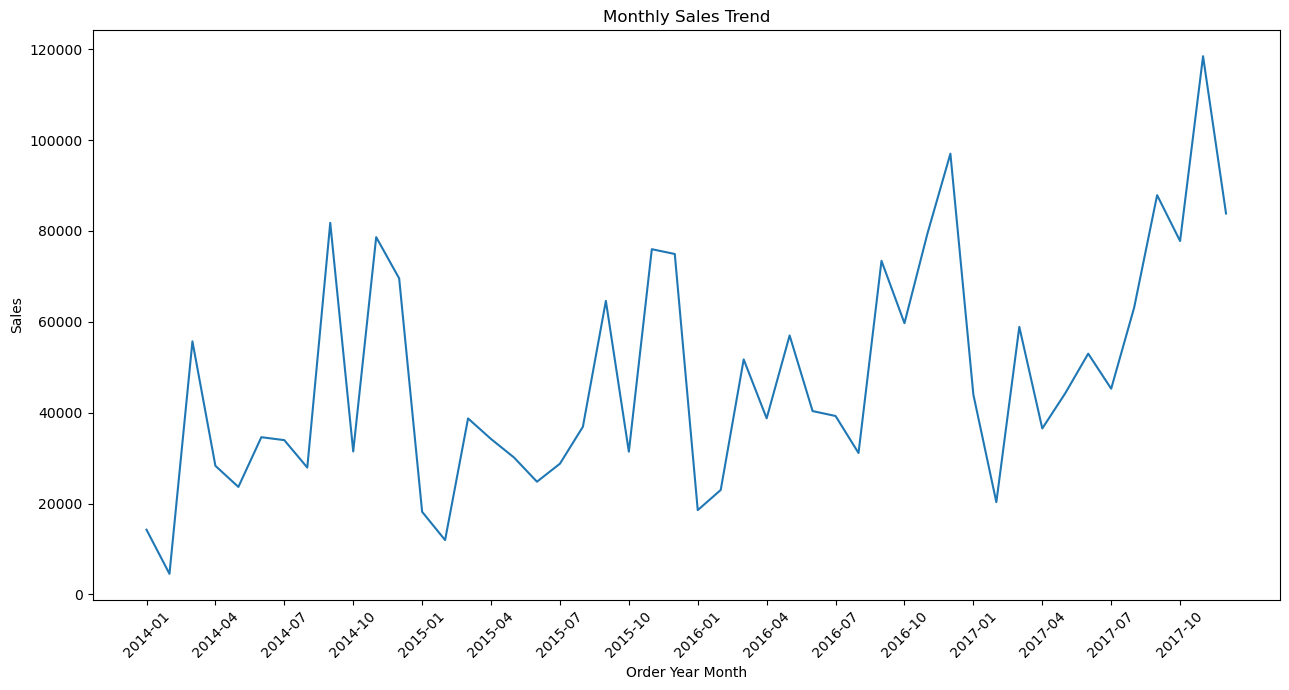

In [18]:
plt.figure(figsize=(13, 7))
sns.lineplot(x="Order Year Month", y="Sales", data=monthly_sales_df)
plt.title("Monthly Sales Trend")
plt.xticks(monthly_sales_df.index[::3], rotation=45)
plt.tight_layout()
plt.show()

#### Conclusion :-
Sales follow a clear seasonal pattern — significant spikes occur between October and January, 
likely driven by holiday and year-end purchasing. 2017 shows the strongest overall 
sales growth, confirming positive business momentum over the 4-year period.

### -> Monthly Profit Trend

In [19]:
monthly_profit_df = df.groupby("Order Year Month")["Profit"].sum().reset_index()
monthly_profit_df.head(3)

,Order Year Month,Profit
0,2014-01,2450.1907
1,2014-02,862.3084
2,2014-03,498.7299


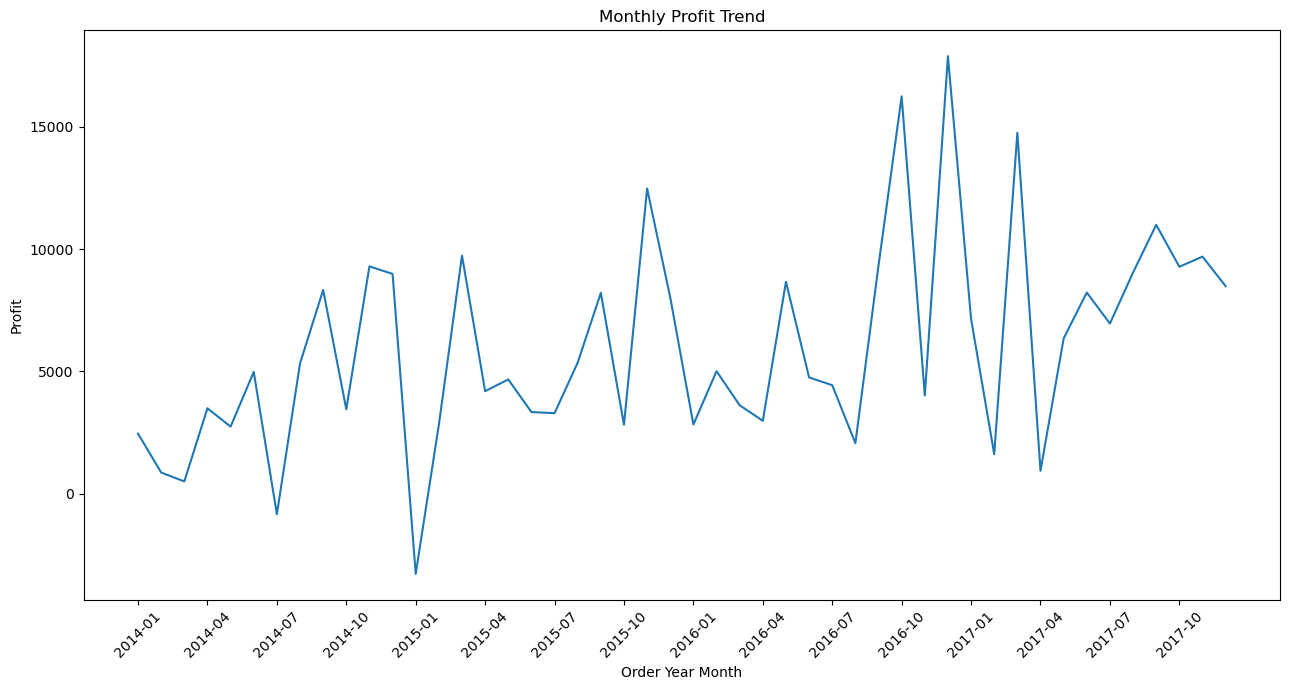

In [20]:
plt.figure(figsize=(13, 7))
sns.lineplot(x="Order Year Month", y="Profit", data=monthly_profit_df)
plt.title("Monthly Profit Trend")
plt.xticks(monthly_profit_df.index[::3], rotation=45)
plt.tight_layout()
plt.show()

#### Conclusion :-
Profit trends don't always mirror sales trends — a key business insight. 
January 2015 recorded a significant loss despite post-holiday sales activity, 
suggesting heavy discounting eroded margins. The period July 2016 to April 2017 
represents the most consistently profitable phase in the dataset.

## 6. Discount Analysis

### -> Average Discount

In [21]:
avg_discount = df["Discount"].mean()
print("Average Discount Offered :",avg_discount)

Average Discount Offered : 0.15620272163297977


#### Conclusion :-
The average discount offered is ~15.6%.

### -> Discount Distribution

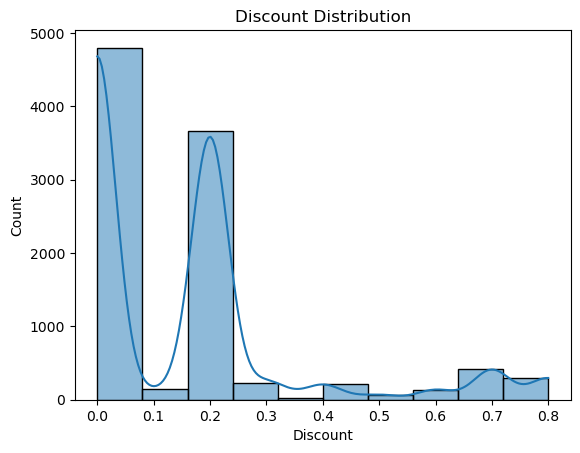

In [22]:
sns.histplot(data=df, x="Discount", bins=10, kde=True)
plt.title("Discount Distribution")
plt.show()

#### Conclusion :-
The Discount Distribution shows that 
a large portion of orders carry 0–20% discounts, but a notable cluster sits 
at 40–80% discount levels — these are almost certainly loss-making transactions.

### -> Relation Between Discount And Profit

In [23]:
corr = df[["Discount", "Profit"]].corr()
corr

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


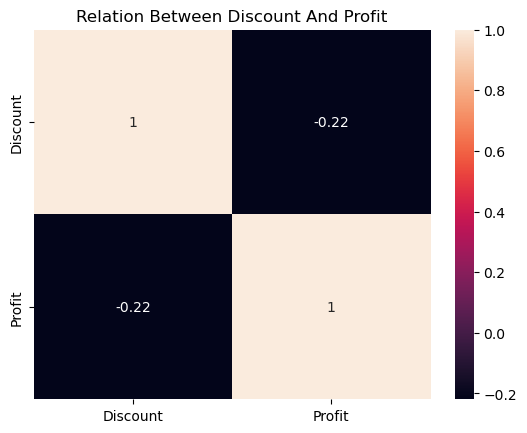

In [24]:
sns.heatmap(corr, annot=True)
plt.title("Relation Between Discount And Profit")
plt.show()

#### Conclusion :-
The correlation between discount and profit is -0.22, confirming that higher 
discounts consistently reduce profitability, though other factors also play a role.

## 7. Customer Analysis

### -> Top 10 Customers By Sales

In [25]:
customer_sales = df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False).head(10)

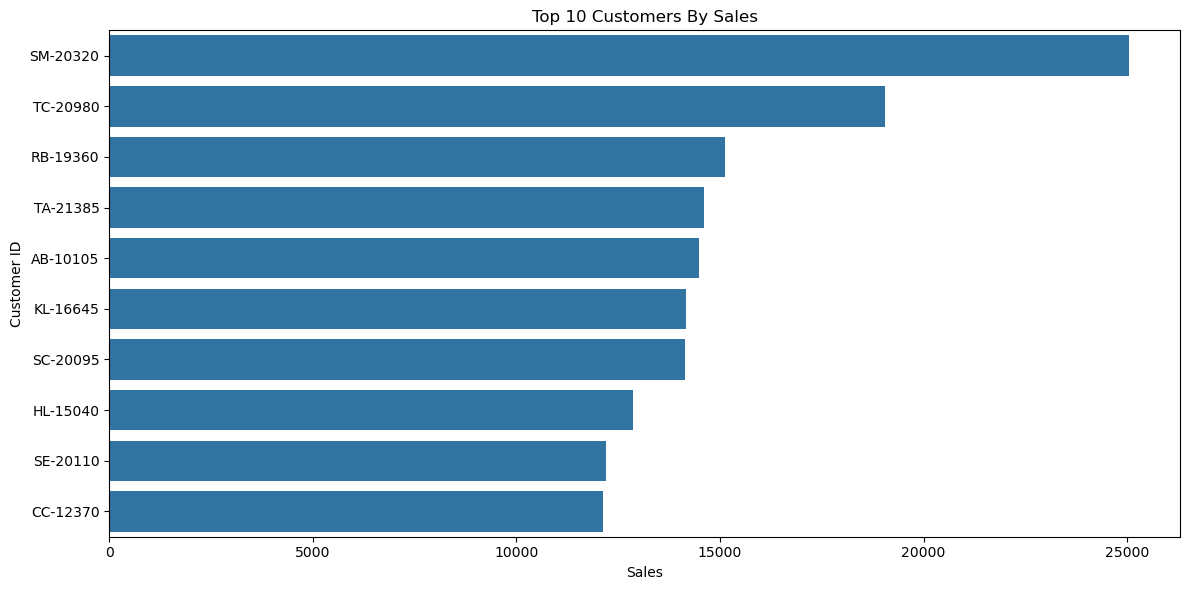

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(x=customer_sales.values, y=customer_sales.index)
plt.title("Top 10 Customers By Sales")
plt.xlabel("Sales")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

#### Conclusion :- 
The top 10 customers by sales — 
a reminder that even a small group of high-value customers can drive disproportionate 
revenue. Retaining these customers through loyalty programs or dedicated account 
management should be a business priority.

### -> Top 10 Customers By Profit

In [27]:
customer_profit = df.groupby("Customer ID")["Profit"].sum().sort_values(ascending=False).head(10)

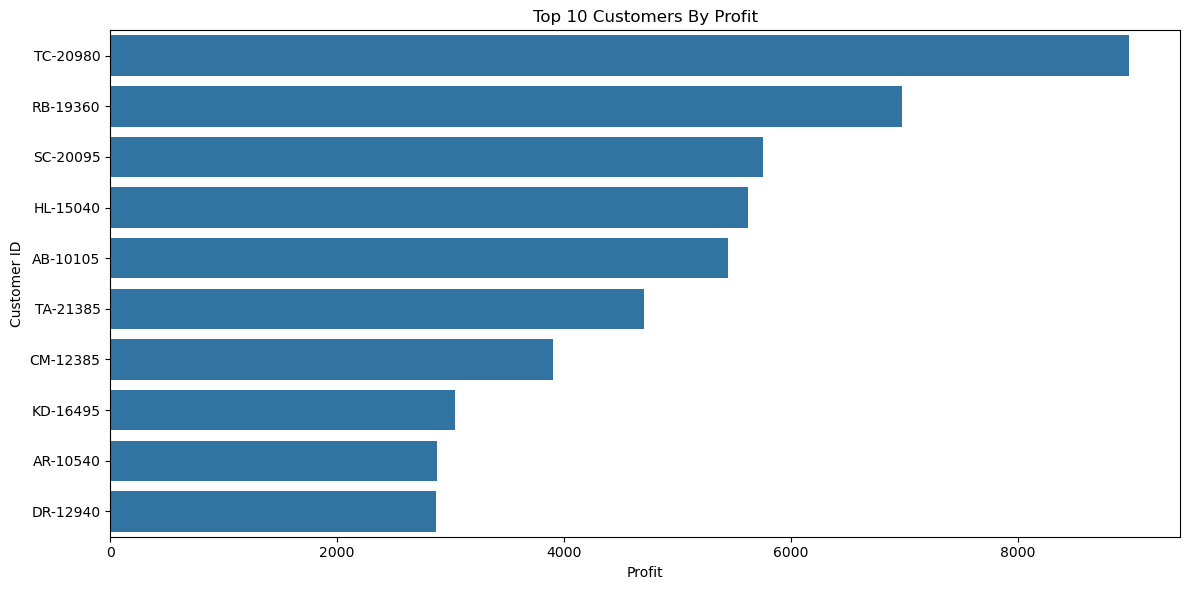

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(x=customer_profit.values, y=customer_profit.index)
plt.title("Top 10 Customers By Profit")
plt.xlabel("Profit")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

#### Conclusion :-
The top profit-generating customers are not identical to the top sales customers — 
confirming that high revenue does not always mean high profitability at the customer level. 
Businesses should prioritize retaining customers who appear in both lists, 
as they represent the highest overall value.

## 8. Product Analysis

### -> Top 10 Products By Sales

In [29]:
product_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

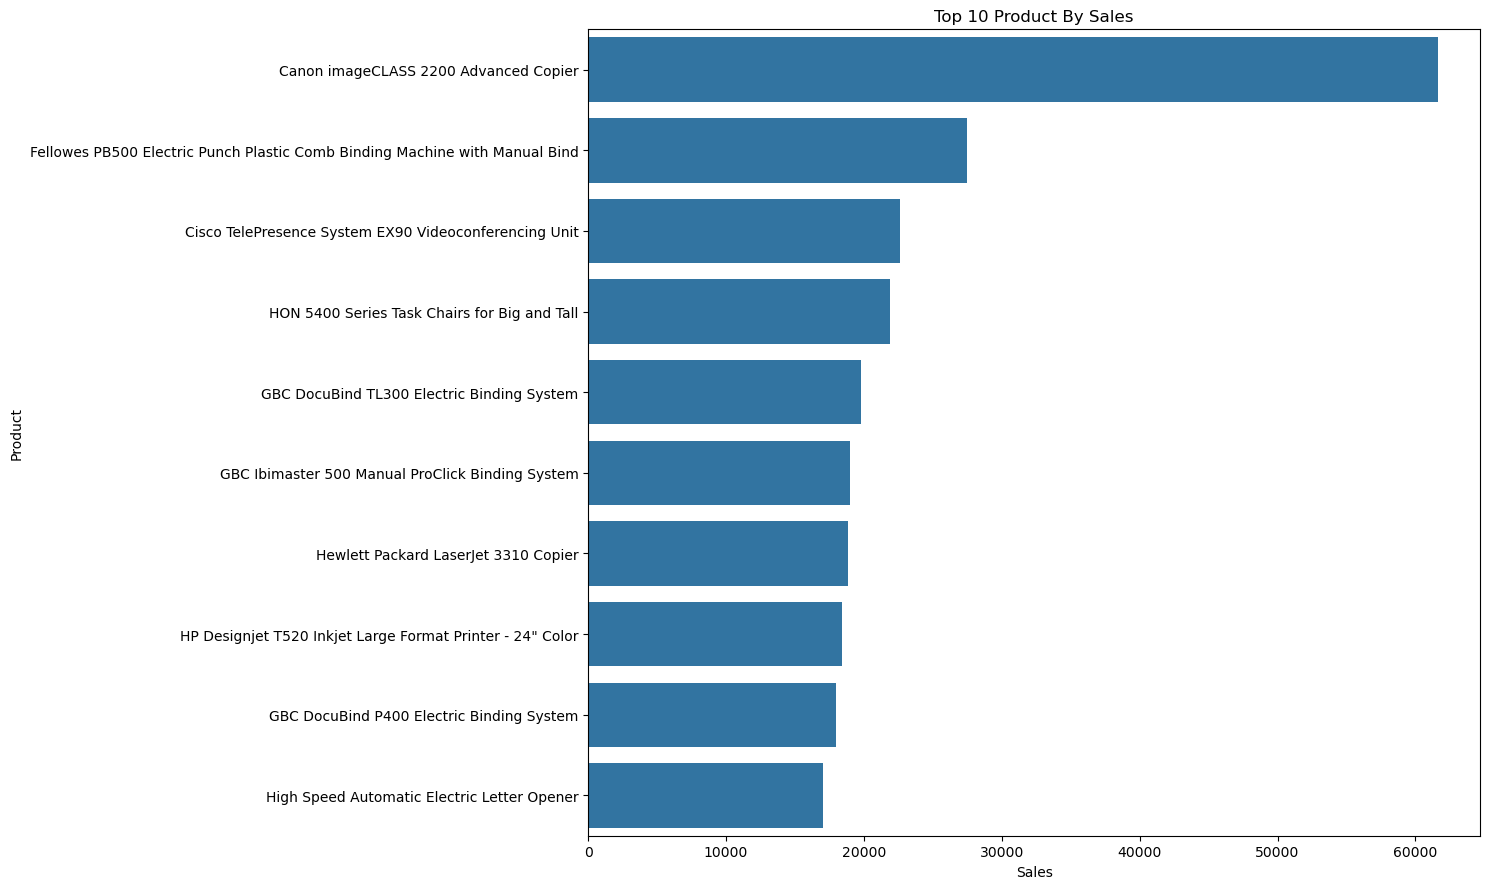

In [30]:
plt.figure(figsize=(15, 9))
sns.barplot(x=product_sales.values, y=product_sales.index)
plt.title("Top 10 Product By Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

#### Conclusion :-
Canon imageCLASS 2200 Advanced Copier is the top-selling product by a significant margin, 
consistent with Copiers being the most profitable sub-category. The top 10 products 
are dominated by high-ticket office equipment — confirming that big-ticket B2B purchases 
drive the most revenue for this business.

### -> Top 10 Products By Profit

In [31]:
product_profit = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

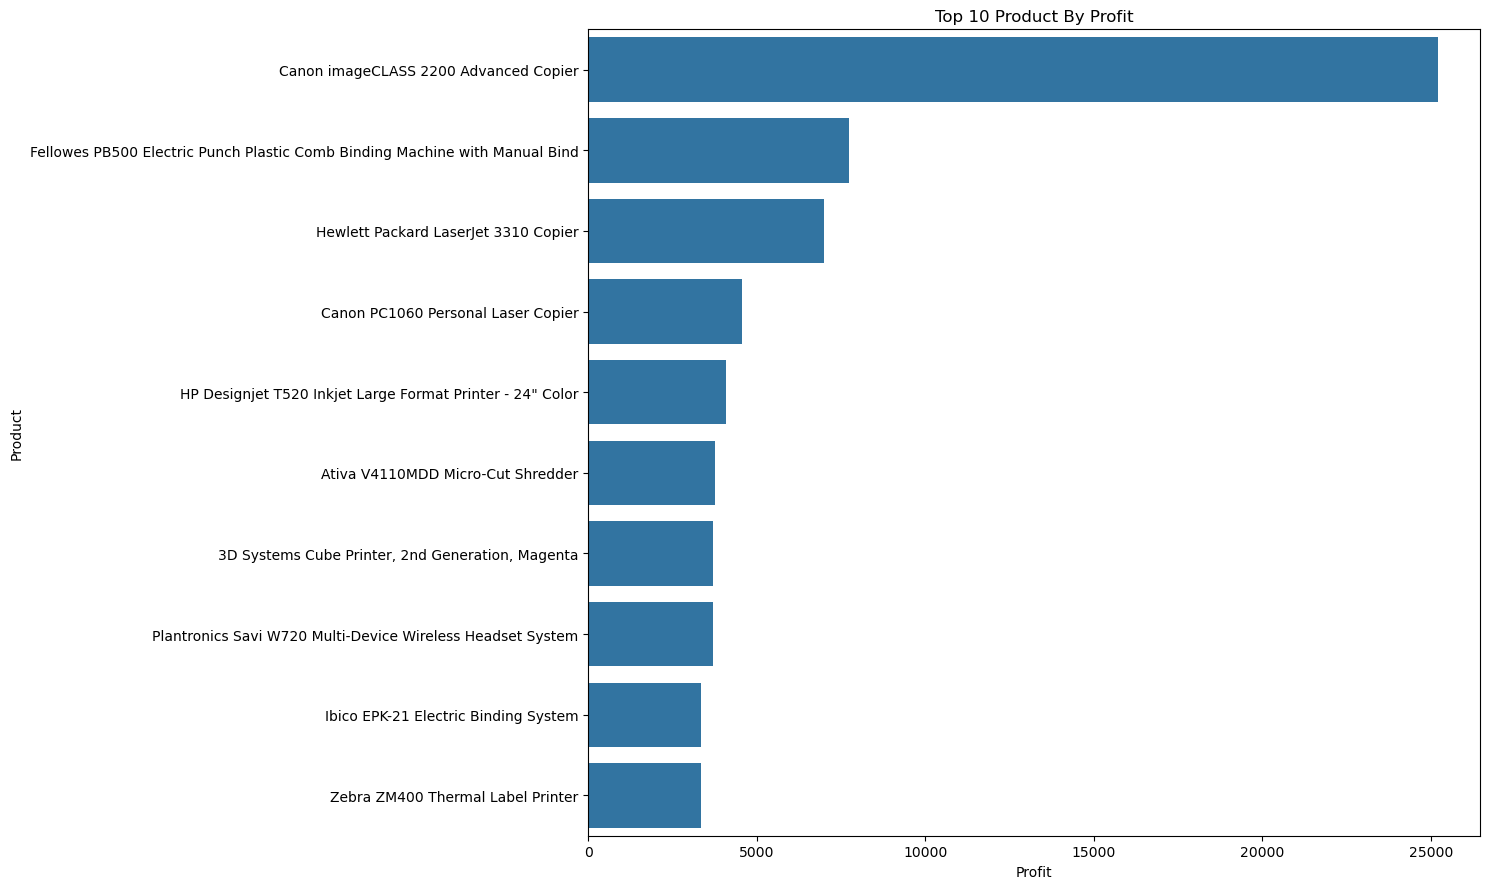

In [32]:
plt.figure(figsize=(15, 9))
sns.barplot(x=product_profit.values, y=product_profit.index)
plt.title("Top 10 Product By Profit")
plt.xlabel("Profit")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

#### Conclusion :-
The most profitable products skew heavily toward Copiers and high-end technology equipment — 
consistent with the sub-category analysis. Notably, the top profit products 
and top sales products overlap but are not identical, reinforcing that 
revenue and margin are separate levers the business must manage independently.

## Business Recommendations

1. **Fix the Furniture problem.** Furniture generates 742K dollars in sales but only 18K
   dollars in profit. Conduct a full pricing and discount audit on Tables and Bookcases — 
   the two biggest loss-makers. Either reprice or discontinue.

2. **Protect and grow Technology.** It is the only category that wins on both 
   revenue and profit. Prioritize inventory, marketing spend, and sales focus here.

3. **Cap discounts at 20%.** Orders with 40%+ discounts are almost certainly 
   loss-making. Implement a discount approval policy above 20%.

4. **Investigate the Central region.** High sales, lowest profit — something is 
   structurally wrong here. Likely over-discounting by regional sales teams.

5. **Prepare for Q4 demand.** Sales spike Oct–Jan every year. Ensure inventory 
   and logistics are ready 6–8 weeks in advance to maximize this window.

6. **Retain top customers.** The top 10 customers represent significant revenue 
   concentration. A churn event here would materially impact the business.